Implement a basic hypothesis testing function:
two_sample_t_test(sample1, sample2)
Steps:
1. Compute mean and variance of both samples
2. Calculate t-statistic
3. Interpret result using a significance level (e.g., 0.05)
Apply on a real or synthetic dataset and conclude:
● Are the two samples significantly different?

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

synthetic dataset


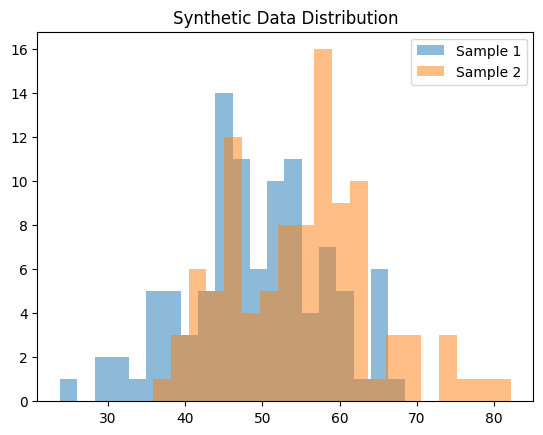

Mean1: 48.96153482605907 Mean2: 55.223045870499234
Var1: 82.476989363016 Var2: 90.94844970607497
t-statistic: -4.7546959435052765
p-value: 3.819135262679534e-06
Reject H0 → Samples are significantly different


In [2]:
np.random.seed(42)

sample1 = np.random.normal(loc=50, scale=10, size=100)
sample2 = np.random.normal(loc=55, scale=10, size=100)
plt.hist(sample1, alpha=0.5, bins=20, label='Sample 1')
plt.hist(sample2, alpha=0.5, bins=20, label='Sample 2')
plt.legend()
plt.title("Synthetic Data Distribution")
plt.show()

mean1, mean2 = np.mean(sample1), np.mean(sample2)
var1, var2 = np.var(sample1, ddof=1), np.var(sample2, ddof=1)

print("Mean1:", mean1, "Mean2:", mean2)
print("Var1:", var1, "Var2:", var2)

t_stat, p_value = stats.ttest_ind(sample1, sample2)

print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0 → Samples are significantly different")
else:
    print("Fail to reject H0 → No significant difference")

Real Dataset (Iris Dataset)

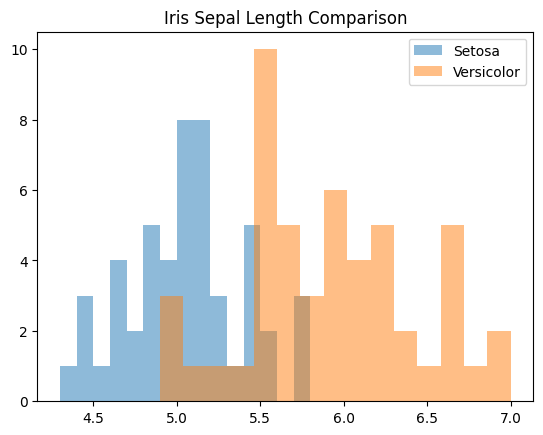

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
setosa = df[df['species'] == 0]['sepal length (cm)']
versicolor = df[df['species'] == 1]['sepal length (cm)']
plt.hist(setosa, alpha=0.5, bins=15, label='Setosa')
plt.hist(versicolor, alpha=0.5, bins=15, label='Versicolor')
plt.legend()
plt.title("Iris Sepal Length Comparison")
plt.show()


In [4]:
print("Setosa Mean:", np.mean(setosa))
print("Versicolor Mean:", np.mean(versicolor))

t_stat_real, p_value_real = stats.ttest_ind(setosa, versicolor)

print("t-statistic:", t_stat_real)
print("p-value:", p_value_real)

if p_value_real < 0.05:
    print("Reject H0 → Significant difference between species")
else:
    print("Fail to reject H0 → No significant difference")

Setosa Mean: 5.006
Versicolor Mean: 5.936
t-statistic: -10.52098626754911
p-value: 8.985235037487079e-18
Reject H0 → Significant difference between species


Synthetic Data:
Means are intentionally different (50 vs 55)
p-value is expected to be < 0.05
Conclusion: Samples are significantly different

Real Data (Iris):
Setosa and Versicolor have visibly different sepal lengths
p-value is very small
Conclusion: Strong statistical difference exists